In [1]:
# E-Commerce Business Intelligence & Customer Analytics
# Exploratory Data Analysis using Python and Pandas

In [2]:
import pandas as pd

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# loading all the dataset

In [5]:
customers = pd.read_csv("Dataset/customers_clean.csv")

In [6]:
orders = pd.read_csv("Dataset/orders_clean.csv")

In [7]:
order_items = pd.read_csv("Dataset/order_item_clean.csv")

In [8]:
payment = pd.read_csv("Dataset/payment_clean.csv")


In [9]:
review = pd.read_csv("Dataset/review_clean.csv")


In [10]:
geolocation = pd.read_csv("Dataset/geolocation_clean.csv")

In [11]:
product = pd.read_csv("Dataset/product_clean.csv")

In [12]:
seller = pd.read_csv("Dataset/seller_clean.csv")

In [13]:
category_translation = pd.read_csv("Dataset/product_category_name_translation.csv")

In [14]:
# printing shape

In [15]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Payments:", payment.shape)
print("Reviews:", review.shape)
print("Geolocation:", geolocation.shape)
print("Products:", product.shape)
print("Sellers:", seller.shape)
print("Category Translation:", category_translation.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Payments: (103886, 5)
Reviews: (99224, 7)
Geolocation: (19015, 5)
Products: (32951, 9)
Sellers: (3095, 4)
Category Translation: (71, 2)


In [16]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [17]:
order_status_percentage=orders["order_status"].value_counts(normalize=True).mul(100).round(2)

order_status_percentage

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

In [18]:
# Calculate total payment value to understand the overall revenue generated.

In [19]:
payment["payment_value"].sum()

np.float64(16008872.120000001)

In [20]:
#How much total payment value is recorded in the e-commerce dataset?

In [21]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [22]:
Date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in Date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [23]:
orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [24]:
orders["order_month"]=orders["order_purchase_timestamp"].dt.to_period('M')

monthly_orders=orders["order_month"].value_counts().sort_index()
monthly_orders

order_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

In [25]:
# Visualize monthly order volume to identify overall demand trends.

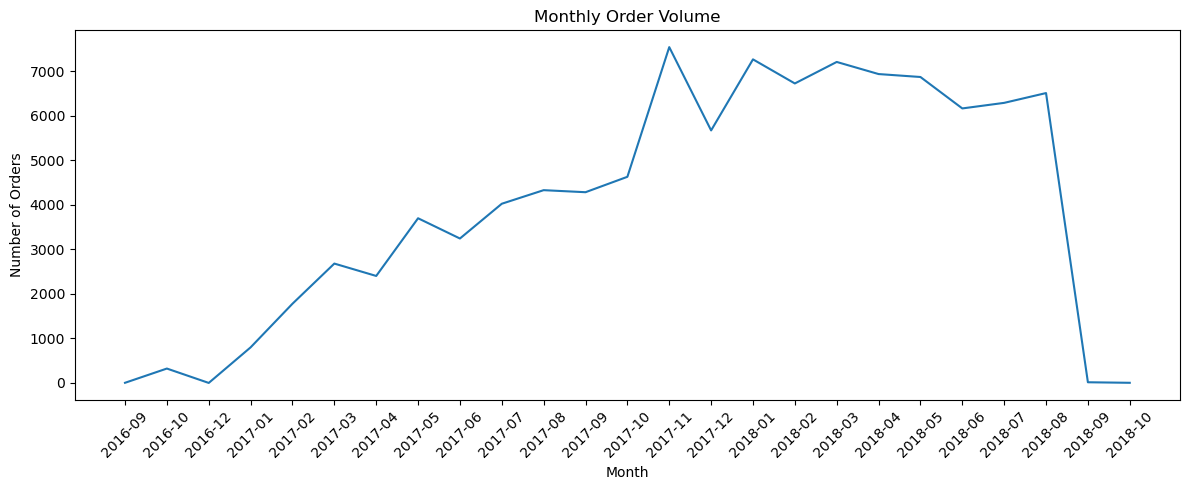

In [26]:
plt.figure(figsize=(12,5))
plt.plot(monthly_orders.index.astype(str),monthly_orders.values)
plt.title("Monthly Order Volume")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
#How does customer demand change over time?
#How many orders were placed each month, and which months had the highest demand?
#Order volume grew substantially through 2017 and remained strong throughout most of 2018, with November
#2017 recording the highest monthly order volume.

In [28]:
# Combine order dates with payment data to analyze payment value over time.

In [29]:
order_payment=orders[["order_id","order_purchase_timestamp"]].merge(payment[["order_id", "payment_value"]],on="order_id",how="inner")

In [30]:
order_payment

,order_id,order_purchase_timestamp,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,179.12
...,...,...,...
103881,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05,85.08
103882,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,195.00
103883,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43,271.01
103884,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,441.16


In [31]:
order_payment["order_month"]=order_payment["order_purchase_timestamp"].dt.to_period("M")

In [32]:
order_payment.head()

,order_id,order_purchase_timestamp,payment_value,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,18.12,2017-10
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2.00,2017-10
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,18.59,2017-10
3,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,141.46,2018-07
4,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,179.12,2018-08


In [33]:
monthly_payment=order_payment.groupby("order_month")["payment_value"].sum().sort_index()
monthly_payment

order_month
2016-09        252.24
2016-10      59090.48
2016-12         19.62
2017-01     138488.04
2017-02     291908.01
2017-03     449863.60
2017-04     417788.03
2017-05     592918.82
2017-06     511276.38
2017-07     592382.92
2017-08     674396.32
2017-09     727762.45
2017-10     779677.88
2017-11    1194882.80
2017-12     878401.48
2018-01    1115004.18
2018-02     992463.34
2018-03    1159652.12
2018-04    1160785.48
2018-05    1153982.15
2018-06    1023880.50
2018-07    1066540.75
2018-08    1022425.32
2018-09       4439.54
2018-10        589.67
Freq: M, Name: payment_value, dtype: float64

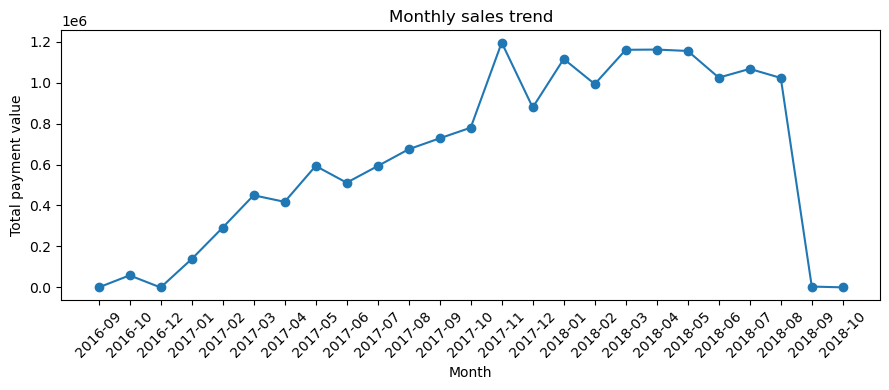

In [34]:
plt.figure(figsize=(9,4))
plt.plot(monthly_payment.index.astype(str),monthly_payment.values,marker='o')
plt.title("Monthly sales trend")
plt.xlabel("Month")
plt.ylabel("Total payment value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# November 2017 recorded the highest order volume (7,544) and the highest payment value (~1.19M),
# indicating that the highest customer demand was accompanied by the highest payment value.

In [36]:
average_order_value=payment["payment_value"].sum()/payment["order_id"].nunique()
average_order_value

np.float64(160.9902666934835)

In [37]:
# The Average Order Value (AOV) is approximately $160.99,
# meaning customers paid about $160.99 per order on average.

In [38]:
payment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [39]:
payment_counts=payment["payment_type"].value_counts()
payment_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

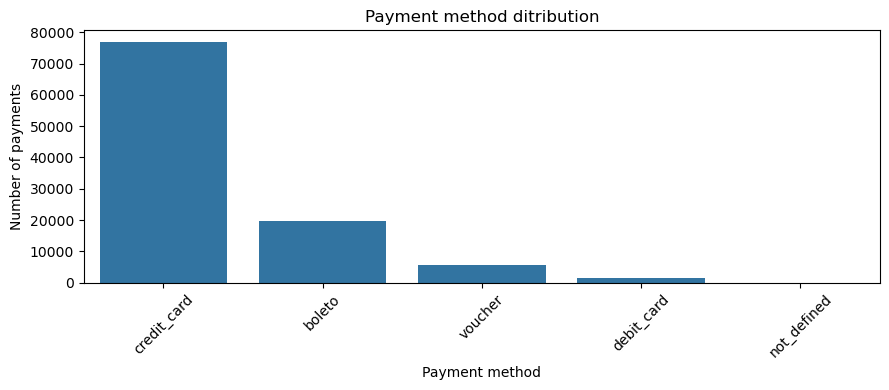

In [40]:
plt.figure(figsize=(9,4))
sns.barplot(x=payment_counts.index,y=payment_counts.values)
plt.title("Payment method ditribution")
plt.xlabel("Payment method")
plt.ylabel("Number of payments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
# Analyze payment method usage to understand customer payment preferences.
# Analyze payment value by payment method to identify the methods contributing the most revenue.

In [42]:
payment_by_type=payment.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False)
payment_by_type

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

In [43]:
#Which payment methods do customers use most, and how much payment value does each method generate?

In [44]:
# Credit card is the dominant payment method, with the highest number of payment records
# and the highest total payment value, indicating a strong customer preference for credit cards.

In [45]:
## Calculate each payment method's percentage contribution to total payment value.

In [46]:
payment_value_percentage=(payment_by_type/payment_by_type.sum()*100).round(2)

payment_value_percentage

payment_type
credit_card    78.34
boleto         17.92
voucher         2.37
debit_card      1.36
not_defined     0.00
Name: payment_value, dtype: float64

In [47]:
#Credit cards account for 78.34% of total payment value, making them the dominant payment method,
# while boleto contributes 17.92% and other methods account for a much smaller share.

In [48]:
#Which product categories generate the most sales?

In [49]:
# Combine order items with product information to analyze sales by product category.

In [50]:
order_product=order_items[["order_id","product_id","price"]].merge(product[["product_id","product_category_name"]],on="product_id",how="left")
order_product

,order_id,product_id,price,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,ferramentas_jardim
...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,4aa6014eceb682077f9dc4bffebc05b0,299.99,utilidades_domesticas
112646,fffcd46ef2263f404302a634eb57f7eb,32e07fd915822b0765e448c4dd74c828,350.00,informatica_acessorios
112647,fffce4705a9662cd70adb13d4a31832d,72a30483855e2eafc67aee5dc2560482,99.90,esporte_lazer
112648,fffe18544ffabc95dfada21779c9644f,9c422a519119dcad7575db5af1ba540e,55.99,informatica_acessorios


In [51]:
category_sales=order_product.groupby("product_category_name")["price"].sum().sort_values(ascending=False)
category_sales

product_category_name
beleza_saude                     1258681.34
relogios_presentes               1205005.68
cama_mesa_banho                  1036988.68
esporte_lazer                     988048.97
informatica_acessorios            911954.32
                                    ...    
flores                              1110.04
casa_conforto_2                      760.27
cds_dvds_musicais                    730.00
fashion_roupa_infanto_juvenil        569.85
seguros_e_servicos                   283.29
Name: price, Length: 74, dtype: float64

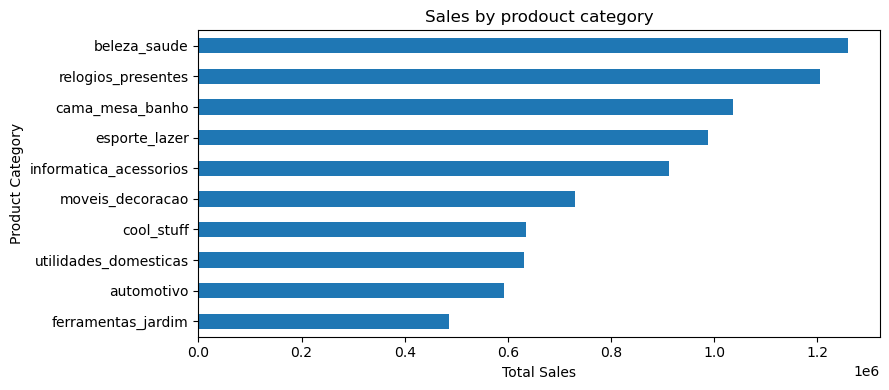

In [52]:
top_10_categories = category_sales.head(10)
plt.figure(figsize=(9,4))
top_10_categories.sort_values().plot(kind="barh")

plt.title("Sales by prodouct category")
plt.xlabel("Total Sales")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

In [53]:
## Beauty & Health (beleza_saude) generated the highest sales,
# while Insurance & Services (seguros_e_servicos) generated among the lowest sales.

In [54]:
#Are there any purchased items without a matching product category?
order_product["product_category_name"].isna().sum()

np.int64(0)

In [55]:
# Identify the individual products generating the highest sales.

In [56]:
product_sales=order_product.groupby("product_id")["price"].sum().sort_values(ascending=False)

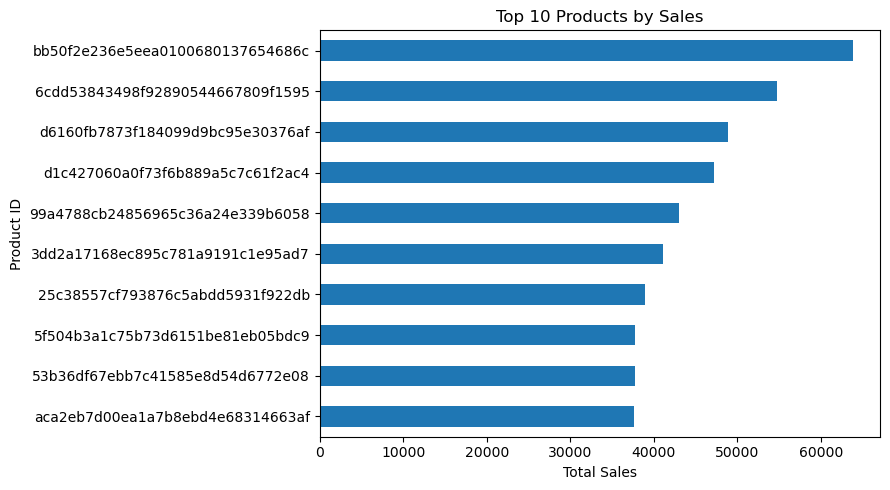

In [57]:
top_10_products = product_sales.head(10)
plt.figure(figsize=(9,5))
top_10_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product ID")
plt.tight_layout()
plt.show()


In [58]:
product_sales.head()

product_id
bb50f2e236e5eea0100680137654686c    63885.00
6cdd53843498f92890544667809f1595    54730.20
d6160fb7873f184099d9bc95e30376af    48899.34
d1c427060a0f73f6b889a5c7c61f2ac4    47214.51
99a4788cb24856965c36a24e339b6058    43025.56
Name: price, dtype: float64

In [59]:
#What are the names/categories of the top-selling products?

In [60]:
top_product=product_sales.head(10).reset_index().merge(product[["product_id","product_category_name"]],on="product_id",how="left")
top_product

,product_id,price,product_category_name
0,bb50f2e236e5eea0100680137654686c,63885.00,beleza_saude
1,6cdd53843498f92890544667809f1595,54730.20,beleza_saude
2,d6160fb7873f184099d9bc95e30376af,48899.34,pcs
3,d1c427060a0f73f6b889a5c7c61f2ac4,47214.51,informatica_acessorios
4,99a4788cb24856965c36a24e339b6058,43025.56,cama_mesa_banho
5,3dd2a17168ec895c781a9191c1e95ad7,41082.60,informatica_acessorios
6,25c38557cf793876c5abdd5931f922db,38907.32,bebes
7,5f504b3a1c75b73d6151be81eb05bdc9,37733.90,cool_stuff
8,53b36df67ebb7c41585e8d54d6772e08,37683.42,relogios_presentes
9,aca2eb7d00ea1a7b8ebd4e68314663af,37608.90,moveis_decoracao


In [61]:
# Several of the highest-selling individual products belong to the Beauty & Health
# and Informatics Accessories categories, indicating strong sales from these categories.

In [62]:
#How much does each product category contribute to total sales?

In [63]:
category_sales_percentage=(category_sales/category_sales.sum()*100).round(2)
category_sales_percentage.head(10)

product_category_name
beleza_saude              9.26
relogios_presentes        8.87
cama_mesa_banho           7.63
esporte_lazer             7.27
informatica_acessorios    6.71
moveis_decoracao          5.37
cool_stuff                4.67
utilidades_domesticas     4.65
automotivo                4.36
ferramentas_jardim        3.57
Name: price, dtype: float64

In [64]:
# Beauty & Health contributes the largest share of product sales at 9.26%,
# followed by Watches & Gifts (8.87%) and Bed, Bath & Table (7.63%).

In [65]:
#How many unique customers does the business have, and how many orders does each customer place?

In [66]:
unique_customer=customers["customer_unique_id"].nunique()
unique_customer

96096

In [67]:
# The dataset contains 96,096 unique customers based on customer_unique_id.

In [68]:
customer_orders=(orders.merge(customers[["customer_id","customer_unique_id"]],
    on="customer_id",how="left")).groupby("customer_unique_id")["order_id"].nunique()

In [69]:
customer_orders.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
Name: order_id, dtype: int64

In [70]:
#How many customers purchased more than once?

In [71]:
repeat_customers=(customer_orders>1).sum()

repeat_customers

np.int64(2997)

In [72]:
repeat_customer_percentage=(repeat_customers/unique_customer*100).round(2)
repeat_customer_percentage


np.float64(3.12)

In [73]:
# Only 3.12% of unique customers are repeat customers,
# indicating that most customers made a one-time purchase in the dataset.

In [74]:
customer_type=pd.Series(np.where(customer_orders>1,"Repeat Customer", "One-Time Customer"),index=customer_orders.index)

customer_type.value_counts()

One-Time Customer    93099
Repeat Customer       2997
Name: count, dtype: int64

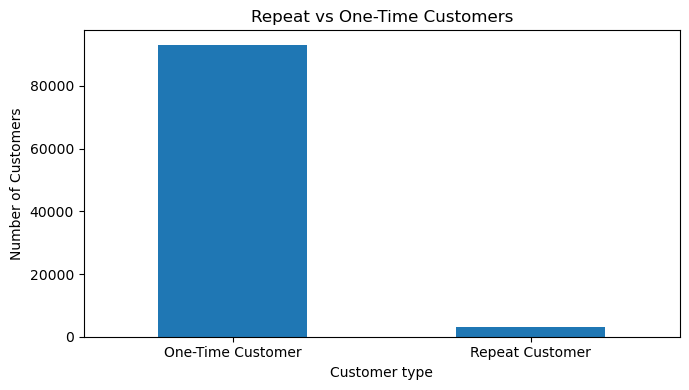

In [75]:
customer_type.value_counts().plot(kind="bar",figsize=(7,4))
plt.title("Repeat vs One-Time Customers")
plt.xlabel("Customer type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [76]:
# The dataset contains 93,099 one-time customers and 2,997 repeat customers,
# showing that most customers made only one purchase.

In [77]:
# Analyze the distribution of orders per customer to understand customer purchasing frequency.

In [78]:
customer_order_distribution=customer_orders.value_counts().sort_index()

customer_order_distribution

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [79]:
customer_order_distribution.index.name="orders_per_customer"
customer_order_distribution

orders_per_customer
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [80]:
#Which customer states generate the most sales?

In [81]:
order_customer=orders.merge(customers[["customer_id","customer_state"]],on="customer_id",how="left")

In [82]:
order_customer_sales=order_customer.merge(order_items[["order_id","price"]],on="order_id",how="left")

In [83]:
order_customer_sales

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,customer_state,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,SP,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,BA,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,GO,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,RN,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,SP,19.90
...,...,...,...,...,...,...,...,...,...,...,...
113420,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,2018-02,SP,174.90
113421,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,2017-08,BA,205.99
113422,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2018-01,RJ,179.99
113423,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2018-01,RJ,179.99


In [84]:
# calculating sales
state_sales=order_customer_sales.groupby("customer_state")["price"].sum().sort_values(ascending=False)
state_sales

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
PE     262788.03
CE     227254.71
PA     178947.81
MT     156453.53
MA     119648.22
MS     116812.64
PB     115268.08
PI      86914.08
RN      83034.98
AL      80314.81
SE      58920.85
TO      49621.74
RO      46140.64
AM      22356.84
AC      15982.95
AP      13474.30
RR       7829.43
Name: price, dtype: float64

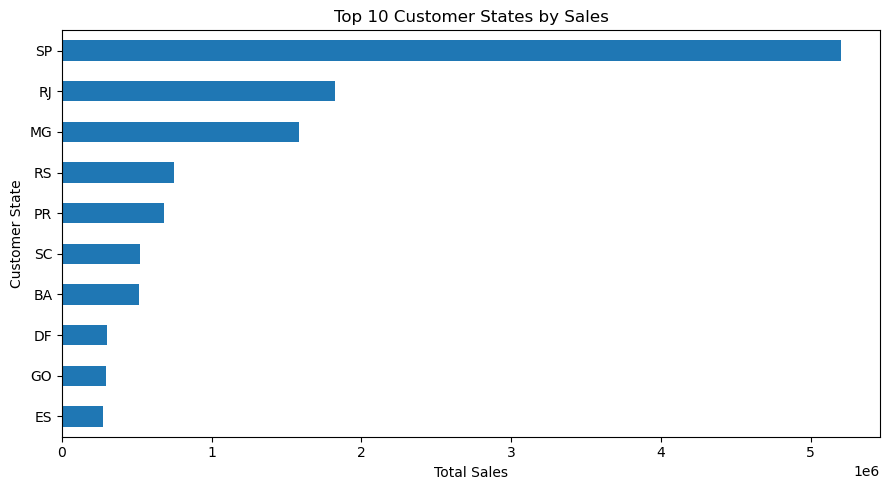

In [85]:
top_10_states = state_sales.head(10)
plt.figure(figsize=(9, 5))
top_10_states.sort_values().plot(kind="barh")
plt.title("Top 10 Customer States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer State")
plt.tight_layout()
plt.show()

In [86]:
# São Paulo (SP) generates the highest sales, followed by Rio de Janeiro (RJ) and Minas Gerais (MG),
# indicating that sales are concentrated in a few major customer states

In [87]:
#What percentage of total sales comes from each customer state?

In [88]:
state_sales_percentage=(state_sales/state_sales.sum()*100).round(2)
state_sales_percentage

customer_state
SP    38.28
RJ    13.42
MG    11.66
RS     5.52
PR     5.03
SC     3.83
BA     3.76
DF     2.23
GO     2.17
ES     2.02
PE     1.93
CE     1.67
PA     1.32
MT     1.15
MA     0.88
MS     0.86
PB     0.85
PI     0.64
RN     0.61
AL     0.59
SE     0.43
TO     0.37
RO     0.34
AM     0.16
AC     0.12
AP     0.10
RR     0.06
Name: price, dtype: float64

In [89]:
# São Paulo contributes 38.28% of total sales, followed by Rio de Janeiro (13.42%)
# and Minas Gerais (11.66%), showing that sales are highly concentrated in these states.

In [90]:
#How long does it take, on average, to deliver an order to the customer?

In [91]:
orders["delivery_days"]=(orders["order_delivered_customer_date"]-orders["order_purchase_timestamp"]).dt.days

In [92]:
orders["delivery_days"].head(5)

0     8.0
1    13.0
2     9.0
3    13.0
4     2.0
Name: delivery_days, dtype: float64

In [93]:
orders["delivery_days"].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

In [94]:
# The average delivery time is approximately 12.1 days for orders with available delivery dates,
# while the median delivery time is 10 days, indicating that most orders are delivered within about 10 days

In [95]:
orders["delivery_delay_days"]=(orders["order_delivered_customer_date"]-orders["order_estimated_delivery_date"]).dt.days

In [96]:
orders["delivery_delay_days"].head()

0    -8.0
1    -6.0
2   -18.0
3   -13.0
4   -10.0
Name: delivery_delay_days, dtype: float64

In [97]:
#What percentage of delivered orders arrived later than the estimated delivery date?

In [98]:
delivered_orders=orders["delivery_delay_days"].dropna()

late_delivery_rate=((delivered_orders>0).mean()*100).round(2)

late_delivery_rate

np.float64(6.77)

In [99]:
# Only 6.77% of delivered orders arrived after the estimated delivery date,
# while the majority were delivered on or before the estimated date.

In [100]:
#How many orders were delivered early, on the estimated date, and late?

In [101]:
orders["delivery_status"]=np.where(orders["delivery_delay_days"].isna(),"Unkown",
        np.where(orders["delivery_delay_days"]<0,
        "Early",
        np.where(orders["delivery_delay_days"]==0,"On_Time","Late")                                    
)
)

In [102]:
delivery_status_count=orders["delivery_status"].value_counts()
delivery_status_count

delivery_status
Early      88649
Late        6535
Unkown      2965
On_Time     1292
Name: count, dtype: int64

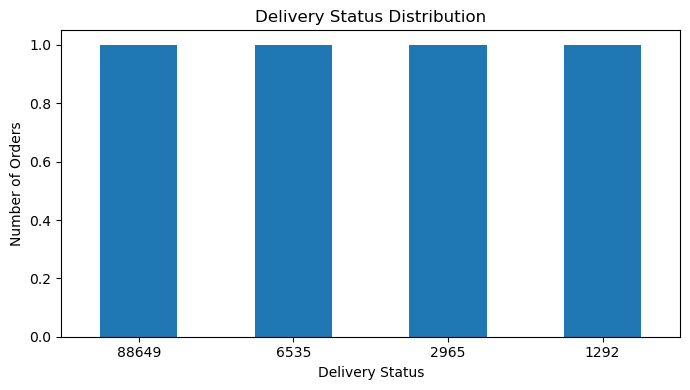

In [103]:
delivery_status_count.value_counts().plot( kind="bar",figsize=(7, 4))
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [104]:
# Most orders were delivered early (88,649), while 6,535 orders were delivered late
# and 1,292 were delivered exactly on the estimated date.

In [105]:
#What percentage of orders were delivered early, on time, and late?

In [106]:
delivery_status_percentage=(delivery_status_count/delivery_status_count.sum()*100).round(2)
delivery_status_percentage

delivery_status
Early      89.15
Late        6.57
Unkown      2.98
On_Time     1.30
Name: count, dtype: float64

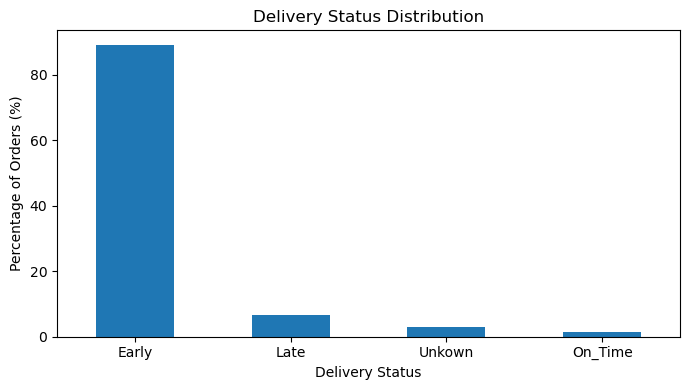

In [107]:
delivery_status_percentage.plot(kind="bar",figsize=(7, 4))
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Percentage of Orders (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [108]:
#Most orders (89.15%) were delivered earlier than the estimated date, while 6.57% were delivered late.

In [109]:
# What is the distribution of customer review scores?

In [110]:
review_score_distribution=review["review_score"].value_counts().sort_index()
review_score_distribution

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

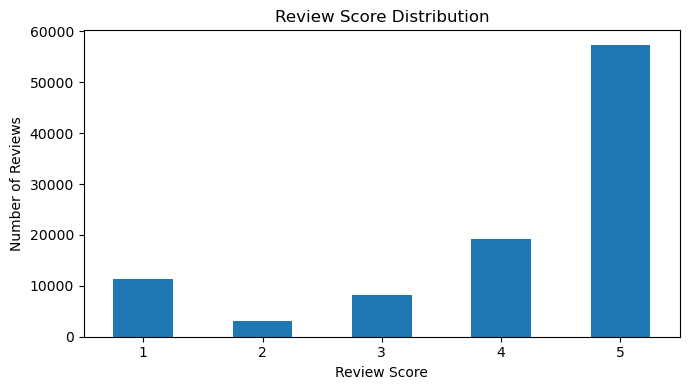

In [111]:
review_score_distribution.plot(kind="bar",figsize=(7, 4))
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [112]:
# 5-star reviews are the most common, followed by 4-star reviews,
# indicating that a large share of customers gave positive ratings.

In [113]:
average_review_score=review["review_score"].mean().round(2)
average_review_score

np.float64(4.09)

In [114]:
positive_review=review["review_score"].isin([4,5]).sum()
negative_review=review["review_score"].isin([1,2]).sum()

postive_percentage=(positive_review/len(review)*100).round(2)
negative_percentage=(negative_review/len(review)*100).round(2)

In [115]:
postive_percentage

np.float64(77.07)

In [116]:
negative_percentage

np.float64(14.69)

In [117]:
# 77.07% of reviews were positive (4–5 stars), while 14.69% were negative (1–2 stars),
# indicating that most customers gave favorable ratings.

In [118]:
#Do late deliveries have lower review scores than early deliveries?

In [119]:
order_review=orders[["order_id","delivery_status"]].merge(review[["order_id","review_score"]],on="order_id",how="inner")

In [120]:
average_review_by_delivery=order_review.groupby("delivery_status")["review_score"].mean().round(2)
average_review_by_delivery

delivery_status
Early      4.29
Late       2.27
On_Time    4.03
Unkown     1.76
Name: review_score, dtype: float64

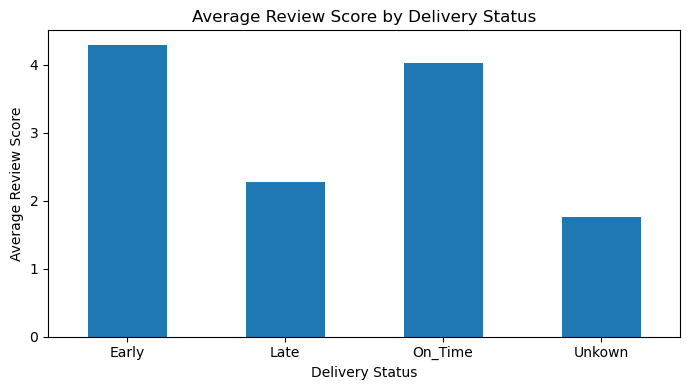

In [149]:
average_review_by_delivery.plot(kind="bar",figsize=(7, 4))
plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [121]:
# Late deliveries had a much lower average review score (2.27) than early deliveries (4.29),
# indicating a strong association between late delivery and lower customer satisfaction.

In [122]:
late_orders=order_review[order_review["delivery_status"]=="Late"]
low_rating_low_orders=late_orders["review_score"].isin([1,2]).sum()

low_rating_low_orders

np.int64(4000)

In [123]:
len(late_orders)

6410

In [124]:
low_rating_percentage=(low_rating_low_orders/len(late_orders)*100).round(2)

In [125]:
low_rating_percentage

np.float64(62.4)

In [126]:
# 62.40% of late-delivery orders received a low rating (1–2 stars),
# indicating a strong association between late delivery and customer dissatisfaction.

In [127]:
#Which product categories have the highest and lowest average customer ratings?

In [128]:
review_product=review[["order_id","review_score"]].merge(
    order_items[["order_id","product_id"]],on="order_id",how="inner"
).merge(product[["product_id","product_category_name"]],on="product_id",how="left")


review_product

,order_id,review_score,product_id,product_category_name
0,73fc7af87114b39712e6da79b0a377eb,4,fd25ab760bfbba13c198fa3b4f1a0cd3,esporte_lazer
1,73fc7af87114b39712e6da79b0a377eb,4,fd25ab760bfbba13c198fa3b4f1a0cd3,esporte_lazer
2,a548910a1c6147796b98fdf73dbeba33,5,be0dbdc3d67d55727a65d4cd696ca73c,informatica_acessorios
3,f9e4b658b201a9f2ecdecbb34bed034b,5,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios
4,658677c97b385a9be170737859d3511b,5,52c80cedd4e90108bf4fa6a206ef6b03,ferramentas_jardim
...,...,...,...,...
112367,2a8c23fee101d4d5662fa670396eb8da,5,4fb209073dc2ab6a6d3c259a7c285501,moveis_decoracao
112368,22ec9f0669f784db00fa86d035cf8602,5,3a33c980b62eb1ef3b8ae61b6fc6fe55,brinquedos
112369,55d4004744368f5571d1f590031933e4,5,8ba0118a487ec8671aed57e5ef846574,papelaria
112370,7725825d039fc1f0ceb7635e3f7d9206,4,73a7fbf8c1048131f3b531af31bcdf0e,esporte_lazer


In [129]:
category_review_score=review_product.groupby("product_category_name")["review_score"].mean().sort_values(ascending=False).round(2)
category_review_score

product_category_name
cds_dvds_musicais                                4.64
fashion_roupa_infanto_juvenil                    4.50
livros_interesse_geral                           4.45
construcao_ferramentas_ferramentas               4.44
flores                                           4.42
                                                 ... 
moveis_escritorio                                3.49
pc_gamer                                         3.33
portateis_cozinha_e_preparadores_de_alimentos    3.27
fraldas_higiene                                  3.26
seguros_e_servicos                               2.50
Name: review_score, Length: 74, dtype: float64

In [130]:
# CDs & DVDs received the highest average rating (4.64),
# while Insurance & Services received the lowest average rating (2.50).

In [131]:
#Which product categories have the highest percentage of low ratings (1–2 stars)?

In [132]:
low_rating_by_category=review_product.assign(
    low_rating=review_product["review_score"].isin([1,2])
).groupby("product_category_name")["low_rating"].mean().mul(100).round(2).sort_values(ascending=False)

low_rating_by_category

product_category_name
seguros_e_servicos                               50.00
portateis_cozinha_e_preparadores_de_alimentos    33.33
pc_gamer                                         33.33
fashion_roupa_masculina                          28.24
moveis_escritorio                                26.08
                                                 ...  
livros_interesse_geral                            8.56
construcao_ferramentas_ferramentas                8.08
alimentos_bebidas                                 7.89
flores                                            6.45
cds_dvds_musicais                                 0.00
Name: low_rating, Length: 74, dtype: float64

In [133]:
# Insurance & Services had the highest share of low ratings (50%),
# while CDs & DVDs had no low ratings among the reviewed products.

In [134]:
# Which product categories have the most customer reviews?

In [135]:
category_review_count=review_product.groupby("product_category_name")["review_score"].count().sort_values(ascending=False)
category_review_count.head(10)

product_category_name
cama_mesa_banho           11137
beleza_saude               9645
esporte_lazer              8640
moveis_decoracao           8331
informatica_acessorios     7849
utilidades_domesticas      6943
relogios_presentes         5950
telefonia                  4517
ferramentas_jardim         4329
automotivo                 4213
Name: review_score, dtype: int64

In [136]:
# Bed, Bath & Table has the highest number of reviews (11,137),
# followed by Beauty & Health (9,645) and Sports & Leisure (8,640).

In [137]:
# Among categories with a high number of reviews, which have the highest percentage of low ratings?

In [138]:
high_volume_category=category_review_count[category_review_count>=1000].index

high_volume_low_rating=low_rating_by_category.loc[high_volume_category].sort_values(ascending=False)
high_volume_low_rating.head(10)

product_category_name
moveis_escritorio         26.08
Unknown                   22.09
moveis_decoracao          19.46
cama_mesa_banho           18.96
informatica_acessorios    18.61
telefonia                 16.85
bebes                     16.70
relogios_presentes        16.25
ferramentas_jardim        16.08
eletronicos               15.75
Name: low_rating, dtype: float64

In [139]:
# Among categories with at least 1,000 reviews, Office Furniture had the highest share of low ratings (26.08%)

In [140]:
#Which product categories generate high sales but also have a high percentage of low ratings?
category_performance=pd.DataFrame({
    "sales":category_sales,"low_rating_percentage": low_rating_by_category
})
category_performance.sort_values("sales",ascending=False).head(10)

,sales,low_rating_percentage
product_category_name,,
beleza_saude,1258681.34,13.70
relogios_presentes,1205005.68,16.25
cama_mesa_banho,1036988.68,18.96
esporte_lazer,988048.97,14.58
informatica_acessorios,911954.32,18.61
moveis_decoracao,729762.49,19.46
cool_stuff,635290.85,13.12
utilidades_domesticas,632248.66,15.64
automotivo,592720.11,15.26


In [141]:
# Bed, Bath & Table and Computer Accessories generate high sales while also having relatively high shares of low ratings,
# making them categories that may deserve closer attention.

In [142]:
#Which payment methods are associated with higher average order values?
average_payment_by_type=payment.groupby("payment_type")["payment_value"].mean().sort_values(ascending=False).round(2)
average_payment_by_type

payment_type
credit_card    163.32
boleto         145.03
debit_card     142.57
voucher         65.70
not_defined      0.00
Name: payment_value, dtype: float64

In [143]:
# Credit card has the highest average payment value (163.32),
# while voucher payments have the lowest average payment value (65.70).

In [144]:
#Which customer states have the highest average order value?
state_order_totals=order_customer_sales.groupby(["customer_state","order_id"])["price"].sum()

state_aov=state_order_totals.groupby("customer_state").mean().round(2).sort_values(ascending=False)

In [145]:
state_aov

customer_state
PB    215.05
AP    198.15
AC    197.32
AL    194.47
PA    183.54
RO    182.37
TO    177.22
PI    175.58
MT    172.50
RN    171.21
RR    170.20
CE    170.10
SE    168.35
MS    163.37
MA    160.17
PE    159.07
BA    151.29
AM    151.06
GO    145.84
SC    143.13
RJ    141.93
DF    141.40
RS    137.27
MG    136.25
PR    135.40
ES    135.29
SP    124.63
Name: price, dtype: float64

In [146]:
# Paraíba (PB) has the highest average order value at 215.05,
# while São Paulo (SP) has the lowest average order value at 124.63.

In [147]:
# Which sellers generate the highest sales?
seller_sales=order_items.groupby("seller_id")["price"].sum().round(2).sort_values(ascending=False)
seller_sales

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    229472.63
53243585a1d6dc2643021fd1853d8905    222776.05
4a3ca9315b744ce9f8e9374361493884    200472.92
fa1c13f2614d7b5c4749cbc52fecda94    194042.03
7c67e1448b00f6e969d365cea6b010ab    187923.89
                                      ...    
34aefe746cd81b7f3b23253ea28bef39         8.00
702835e4b785b67a084280efca355756         7.60
1fa2d3def6adfa70e58c276bb64fe5bb         6.90
77128dec4bec4878c37ab7d6169d6f26         6.50
cf6f6bc4df3999b9c6440f124fb2f687         3.50
Name: price, Length: 3095, dtype: float64

In [148]:
# The top seller generated approximately 229,472.63 in product sales,
# while the top five sellers generated substantial sales compared with the rest of the sellers.